# Simple neural network example

In this example we will classify iris flower species using a neural network.

Neural networks can work either as regression calculators or as classifiers. In any case NNs are member of the supervised learning methods and require labled input.

## IRIS dataset

(see http://archive.ics.uci.edu/ml/datasets/Iris/)

__Attribute Information:__

1. sepal length \[cm\]
2. sepal width \[cm\]
3. petal length \[cm\]
4. petal width \[cm\]
5. class:
 - Iris Setosa (setosa)
 - Iris Versicolour (versicolor)
 - Iris Virginica (virginica)
 
Total data records: 150 (50/species)

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/7/78/Petal-sepal.jpg/226px-Petal-sepal.jpg"><br>
<caption>Fig. 1: Sepal (protective outer sheet) and Petal (blossom leaves)</caption>

<p>&nbsp;</p>
<table style="align: left; padding: 0;">
    <tr>
        <td>
            <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg/180px-Kosaciec_szczecinkowaty_Iris_setosa.jpg">
        </td>
        <td>
            <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/41/Iris_versicolor_3.jpg/320px-Iris_versicolor_3.jpg">
        </td>
        <td>
            <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/9f/Iris_virginica.jpg/295px-Iris_virginica.jpg">
        </td>
    </tr>
    <tr>
        <td>Setosa</td>
        <td>Versicolour</td>
        <td>Virginica</td>
    <tr>
</table>
<caption>Fig. 2: Different species of irises (classes) in the dataset

Our goal is to model a NN, train it to classify the individual species based on leave characteristics.

## Prepare the environment and data


In [1]:
# imports
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix  
import matplotlib.pyplot as plt


In [2]:
# load iris dataset, use pandas to load
data_train = pd.read_csv('data/iris.csv')

# check Dataframe
data_train.head()

,sepal length,sepal width,petal length,petal width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Species are stored as string types. However, for our algorithms to work, we need to encode them with numerical values (0, 1 and 2). 
# We do this by replacing the species values accordingly. 

data_train.loc[data_train['species']=='Iris-setosa', 'species']=0
data_train.loc[data_train['species']=='Iris-versicolor', 'species']=1
data_train.loc[data_train['species']=='Iris-virginica', 'species']=2

data_train = data_train.apply(pd.to_numeric)

In [4]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  150 non-null    float64
 1   sepal width   150 non-null    float64
 2   petal length  150 non-null    float64
 3   petal width   150 non-null    float64
 4   species       150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [5]:
# Convert the Pandas frame to a numpy matrix (array)
data_train_array = data_train.values 
# or 
# data_train_array = data_train.to_numpy()

In [6]:
# Initialise the random.seed to a specific number (e.g. 42) for reproducable results.
np.random.seed(17)

#### Prepare the dataset

Split the dataset into two distinct sets for training and subsequent tests.

A common split is 80% for training and 20% for testing (70/30 is useful for larger datasets). 'test_size' adjusts the split.

According to common naming conventions, the input vector is asigned to 'X', the data labels - individual values - are asigned to 'y'.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(data_train_array[:,:4],
                                                    data_train_array[:,4],
                                                    test_size=0.2)

## Generate a simple NN

### Experiment 1

<img src="img/v1_one_hidden_layer.png" width="500px"><br>
<caption>Fig. 3: NN with a single hidden layer</caption><br><br>


We will utilise a multilayer perceptron (MLP, topology see [fig 3]). with the following hyperparameters:

1. an input layer with &nbsp;4 neurons representing the 4 features of the iris species
2. a hidden layer with 10 neurons
3. an output layer with 3 neurons representing the 3 classes
4. activation function __relu__ and
5. optimisation using __adam__.

__scikit learn__ offers an implementation of MLP classifier. For further information refer to:

&nbsp;&nbsp;[MLP classifiers in scikit learn](https://scikit-learn.org/stable/modules/neural_networks_supervised.html?highlight=mlp)

&nbsp;&nbsp;[API reference of sklearn.neural_network.MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)

&nbsp;&nbsp;[Visualization of MLP weights](https://scikit-learn.org/stable/auto_examples/neural_networks/plot_mnist_filters.html#sphx-glr-auto-examples-neural-networks-plot-mnist-filters-py)

&nbsp;&nbsp;[Compare Stochastic learning strategies for MLPClassifier](https://scikit-learn.org/stable/auto_examples/neural_networks/plot_mlp_training_curves.html#sphx-glr-auto-examples-neural-networks-plot-mlp-training-curves-py)
  
<br>

#### 1. Define modul

In [8]:
# define the network
mlp1 = MLPClassifier(hidden_layer_sizes=(10,),
                    activation='relu', 
                    solver='adam', 
                    max_iter=350, 
                    batch_size=10, 
                    verbose=True)


In [9]:
# fit the network to the training data
mlp1.fit(X_train, y_train)


Iteration 1, loss = 4.00250272
Iteration 2, loss = 3.40553964
Iteration 3, loss = 2.83501057
Iteration 4, loss = 2.31506032
Iteration 5, loss = 1.83550853
Iteration 6, loss = 1.51090872
Iteration 7, loss = 1.32850876
Iteration 8, loss = 1.24046965
Iteration 9, loss = 1.17041371
Iteration 10, loss = 1.12110589
Iteration 11, loss = 1.07358008
Iteration 12, loss = 1.03679092
Iteration 13, loss = 1.00474070
Iteration 14, loss = 0.97298690
Iteration 15, loss = 0.94589371
Iteration 16, loss = 0.92051278
Iteration 17, loss = 0.89480893
Iteration 18, loss = 0.87292932
Iteration 19, loss = 0.84832888
Iteration 20, loss = 0.82650054
Iteration 21, loss = 0.80645614
Iteration 22, loss = 0.78835510
Iteration 23, loss = 0.76874525
Iteration 24, loss = 0.75254667
Iteration 25, loss = 0.73259700
Iteration 26, loss = 0.71952956
Iteration 27, loss = 0.70244477
Iteration 28, loss = 0.68857793
Iteration 29, loss = 0.67245257
Iteration 30, loss = 0.66097361
Iteration 31, loss = 0.64636006
Iteration 32, los

Iteration 285, loss = 0.07948777
Iteration 286, loss = 0.07705228
Iteration 287, loss = 0.07784224
Iteration 288, loss = 0.07723424
Iteration 289, loss = 0.07692231
Iteration 290, loss = 0.07713531
Iteration 291, loss = 0.07943792
Iteration 292, loss = 0.07640899
Iteration 293, loss = 0.07587269
Iteration 294, loss = 0.07601615
Iteration 295, loss = 0.07640203
Iteration 296, loss = 0.07544157
Iteration 297, loss = 0.07639115
Iteration 298, loss = 0.07644806
Iteration 299, loss = 0.07570033
Iteration 300, loss = 0.07449521
Iteration 301, loss = 0.07520592
Iteration 302, loss = 0.07855861
Iteration 303, loss = 0.07307318
Iteration 304, loss = 0.07550570
Iteration 305, loss = 0.07365299
Iteration 306, loss = 0.07426593
Iteration 307, loss = 0.07338815
Iteration 308, loss = 0.07582690
Iteration 309, loss = 0.07442961
Iteration 310, loss = 0.07351230
Iteration 311, loss = 0.07509967
Iteration 312, loss = 0.07195877
Iteration 313, loss = 0.07312217
Iteration 314, loss = 0.07253805
Iteration 

C:\Users\faruk\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:582: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (350) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(batch_size=10, hidden_layer_sizes=(10,), max_iter=350,
              verbose=True)

#### 2. Evaluate training results


In [10]:
# return the mean accuracy on the given training data and labels.
score_train1 = mlp1.score(X_train, y_train)
print("Trainingsergebnis: {:.3}".format(score_train1))

Trainingsergebnis: 0.983


#### 3. Evaluate model quality
<br>

Now we want to know __how good our prediction__ are (or how good our model generalises).

Lets find all __correct__ and __incorrect classifications__ our model returns when confronted with new, previously unseen data. 

First we predict labels for our test data.  
Then we calculate a __confusion matrix__ based on the error of our predictions (correct - predicted labels). 

In [11]:
# predict results using the trained model using test data
predictions1 = mlp1.predict(X_test)

# and return the confusion matrix
cf1 = confusion_matrix(y_test, predictions1)
print(cf1)  

[[ 7  0  0]
 [ 0 11  0]
 [ 0  1 11]]


We can do (visually) better than this.

In [12]:
# one can visualise the confusion matrix using matplotlib
# define a plotting function for later reuse 

def plot_heatmap(cf):
    # figsize is the size of the confusion matrix times 1.5 in each direction
    fig, ax = plt.subplots(figsize=(cf.shape[0]*1.5,cf.shape[1]*1.5))

    ax.matshow(cf, cmap=plt.cm.Blues, alpha=0.3)

    # label fields
    for i in range(cf.shape[0]):
        for j in range(cf.shape[1]):
            ax.text(x=j, y=i,s=cf[i, j], va='center', ha='center', size='xx-large')
    
    plt.ylabel('True values', fontsize=14)
    plt.xlabel('Predicted values', fontsize=14)
    plt.title('Confusion Matrix', fontsize=18)
    plt.show()


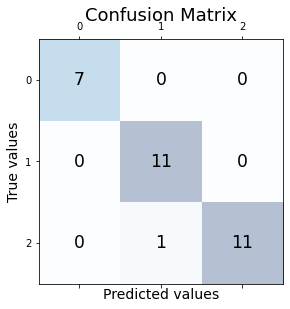

In [13]:
# now plot the confusion matrix
plot_heatmap(cf1)


#### 4. Calculate AI metrics
<br>

Accuracy:&nbsp;&nbsp;How good is our model at predicting correct classes / categories.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Accuracy is weak in dealing with imbalanced data, thus not sufficient on its own.

Precision:&nbsp;How often is the model correct?  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Ratio of what our model predicted correctly to what our model predicted overall.

Recall:&nbsp;&nbsp;&nbsp;&nbsp;How often does it guess right?  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Ratio of what our model predicted correctly to what the actual labels are.

F1-Score:&nbsp;&nbsp;How balanced (overall correctness vs. case correctness) is our model?  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;The harmonic mean of recall and precision warrants for a balance between the two. 

A nice explanation can be found at [Medium](https://medium.com/swlh/explaining-accuracy-precision-recall-and-f1-score-f29d370caaa8) and [Towards data science](https://towardsdatascience.com/whats-the-deal-with-accuracy-precision-recall-and-f1-f5d8b4db1021).

In [14]:
# We can calculate accuracy, precision, recall and F1-score from the confusion matrix
cr1 = classification_report(y_test, predictions1)
print(cr1) 


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         7
         1.0       0.92      1.00      0.96        11
         2.0       1.00      0.92      0.96        12

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [15]:
# return the mean accuracy on the given test data and and labels.
score_test1 = mlp1.score(X_test, y_test)
print("Trainingsergebnis: {:.3}, Testergebnis: {:.3}".format(score_train1, score_test1))


Trainingsergebnis: 0.983, Testergebnis: 0.967


In [16]:
# This returns the weights of the individual layers

print("WEIGHTS:", mlp1.coefs_)
print("BIASES:", mlp1.intercepts_) 


WEIGHTS: [array([[-2.82928616e-02,  3.98626014e-01, -5.97650566e-02,
         3.60177468e-01,  8.35854375e-02,  4.61691767e-67,
         5.58140154e-01,  3.03496513e-01,  3.98363846e-01,
        -2.26749801e-02],
       [ 6.69030070e-01, -3.14379912e-01, -9.14913685e-02,
         5.20526479e-01, -6.07593114e-01, -3.72425974e-98,
         3.55825014e-01,  6.43137144e-01,  4.05330555e-01,
        -3.71695990e-01],
       [ 5.68242922e-01,  6.41685919e-01, -5.92638144e-02,
        -5.45713391e-01,  1.42606035e+00, -8.59704250e-22,
        -2.29152900e-03,  5.22687734e-01,  1.62946479e-02,
         4.20088178e-02],
       [ 3.74815797e-01,  5.69459224e-01, -2.24764024e-02,
        -6.67575691e-01,  1.20578245e+00, -1.95510383e-20,
        -9.93512796e-01, -1.93401619e-01,  2.19345212e-01,
         1.08464432e+00]]), array([[ 4.95433091e-01, -4.86281052e-01,  4.44882544e-01],
       [-7.49077340e-02, -5.77231816e-02,  3.09369926e-01],
       [ 5.35374686e-02, -8.18924816e-03, -5.34071722e-0

In [17]:
# applying the model to some sample values returns predictions based on our pretrained model
# here we use selected values from our testset with features [sepal-length, sepal-width, 
# petal-length, petal-width]

sample_test_data = [[5.1,3.5,1.4,0.2], 
                    [5.9,3.,5.1,1.8], 
                    [4.9,3.,1.4,0.2], 
                    [5.8,2.7,4.1,1.]]
print(mlp1.predict(sample_test_data))


[0. 2. 0. 1.]


#### 5. Printing loss degradation
<br>

During the iterations (epochs) the model learns and makes less mistakes:

$$Loss =  \sum_{i=1}^n  \big( y_{pred}- \widehat{y} \big) $$

To understand the quality of a model, we want to know, how fast a model converges to a minimal loss (an thus to its optimum). The loss function (loss per epoche) allows us to visualise the convergence of our model.

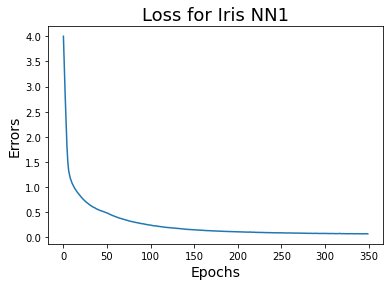

In [18]:
# visualise the loss function and store it

loss_values1 = mlp1.loss_curve_

plt.plot(loss_values1)
plt.title("Loss for Iris NN1", fontsize=18)
plt.xlabel("Epochs", fontsize=14)
plt.ylabel("Errors", fontsize=14)

plt.savefig("./iris_nn1_loss.png")
plt.show()

## Exercise

### Experiment 2

<img src="img/v2_two_hidden_layers.png" width="500px"><br>
<caption>Fig. 4: NN with two hidden layers of different dimensions</caption><br><br>

Define a model with:

1. 2 hidden layers  
  a) layer h1 ... 5 neurons  
  b) layer h2 ... 3 neurons
2. activate using __tanh__
3. optimise using __adam__

Repeat steps 1 to 5 from experiment 1 with these adjusted parameters.


#### 1. Define modul

In [ ]:
# define the network
# mlp2 = 

In [ ]:
# fit the network to the training data


#### 2. Evaluate training results


In [ ]:
# return the mean accuracy on the given training data and labels.



#### 3. Evaluate model quality


In [ ]:
# predict results using the trained model using test data


# and return the confusion matrix
cf2 = np.ones((3,3))
print(cf2)  


In [ ]:
# now plot the confusion matrix
plot_heatmap(cf2)


#### 4. Calculate AI metrics

In [ ]:
# We can calculate accuracy, precision, recall and F1-score from the confusion matrix
# cr2 = 

print(cr2) 


In [ ]:
# return the mean accuracy on the given test data and and labels.
# score_test2 = 
print("Trainingsergebnis: {:.3}, Testergebnis: {:.3}".format(score_train2, score_test2))


In [ ]:
# applying the model to some sample values returns predictions based on our pretrained model
# here we use selected values from our testset with features [sepal-length, sepal-width, 
# petal-length, petal-width]
# sample_test_data = [[5.1,3.5,1.4,0.2], 
#                     [5.9,3.,5.1,1.8], 
#                     [4.9,3.,1.4,0.2], 
#                     [5.8,2.7,4.1,1.]]

print(mlp2.predict(sample_test_data))


#### 5. Printing loss degradation

In [ ]:
# visualise the loss function and store it

# loss_values1 = 

plt.plot(loss_values1)
plt.title("Loss for Iris NN2", fontsize=18)
plt.xlabel("Epochs", fontsize=14)
plt.ylabel("Errors", fontsize=14)

plt.savefig("./iris_nn2_loss.png")
plt.show()

## Model comparison

![img](iris_nn1_loss.png)  ![img](iris_nn2_loss.png)